# Incisos del 4 al 7.

### Importación de librerías.

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix, recall_score
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV
import scipy.stats as stats

### Importación de datos.

In [2]:
df = pd.read_csv('datos_limpios.csv')
df.head(2)

,host_listings_count,host_total_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,room_type_Hotel room,room_type_Private room,room_type_Shared room,calendar_last_scraped_2025-09-16,calendar_last_scraped_2025-09-17,calendar_last_scraped_2025-09-22,calendar_last_scraped_2025-09-23,calendar_last_scraped_2025-09-24,calendar_last_scraped_2025-09-25,calendar_last_scraped_2025-09-30
0,1.0,2.0,30.26057,-97.73441,3,1.0,1.0,2.0,97.0,2,...,0,0,0,0,1,0,0,0,0,0
1,1.0,2.0,30.26034,-97.76487,2,1.0,1.0,2.0,160.0,3,...,0,0,0,0,1,0,0,0,0,0


### Estadísticas del objetivo.

In [3]:
df['price'].describe()

count    73549.000000
mean       769.542958
std       4326.270197
min          8.000000
25%        120.000000
50%        194.000000
75%        330.000000
max      50123.000000
Name: price, dtype: float64

### Manejo de NaN

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 73549 entries, 0 to 164211
Data columns (total 67 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   host_listings_count                           73549 non-null  float64
 1   host_total_listings_count                     73549 non-null  float64
 2   latitude                                      73549 non-null  float64
 3   longitude                                     73549 non-null  float64
 4   accommodates                                  73549 non-null  int64  
 5   bathrooms                                     73549 non-null  float64
 6   bedrooms                                      73549 non-null  float64
 7   beds                                          73549 non-null  float64
 8   price                                         73549 non-null  float64
 9   minimum_nights                                73549 non-null  int

### Se reemplazará los NaN por las medianas.

In [6]:
df = df.fillna(df.median(numeric_only=True))

Las categorías se harán a partir de los cuartiles. Aquellas que estén debajo del cuartil 1 se denominarán 'Económicas', las que estén entre el primer y el tercer cuartil se denominarán 'Intermedia' y el resto 'Cara'.

### Se crea la categoría y se elimina la variable price. (Inciso 6)

In [7]:
categoria = []
for x in df['price']:
    if x <= 120:
        categoria.append('Económica')
    elif x < 330:
        categoria.append('Intermedia')
    else:
        categoria.append('Cara')
df = df.drop(columns=['price'])

### Separación de datos (Inciso 1)

In [8]:
X_train, X_test, y_train, y_test = train_test_split(df, categoria, test_size=0.2, random_state=42, stratify=categoria)

### Transformación de los datos (Inciso 2)

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Para utilizar el modelo SVM es necesario escalar los datos, además todas las variables son continuas para asegurar el funcionamiento del modelo. 

### Modelos. (Inciso 3 y 4)

In [ ]:
param_dist = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100, 1000], 
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1, 10],
    'degree': [2, 3, 4, 5] 
}

modelo_base = svm.SVC()

busqueda_aleatoria = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions=param_dist,
    n_iter=20, 
    scoring='accuracy', 
    cv=5, 
    random_state=42, 
    n_jobs=-1 
)


print("Buscando los mejores hiperparámetros. Esto puede tardar un momento...")
busqueda_aleatoria.fit(X_train, y_train)

print("\n¡Búsqueda terminada!")
print(f"Mejor valor de Recall encontrado: {busqueda_aleatoria.best_score_:.4f}")
print("Mejores parámetros encontrados:")
print(busqueda_aleatoria.best_params_)

mejor_modelo = busqueda_aleatoria.best_estimator_

Buscando los mejores hiperparámetros. Esto puede tardar un momento...


### Predecir Variable Respuesta. (Inciso 5)

In [ ]:
y_pred = mejor_modelo.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Exactitud del modelo:", accuracy)

Exactitud del modelo: 0.791638341264446


### Errores del modelo. (Inciso 6)

<Figure size 800x600 with 0 Axes>

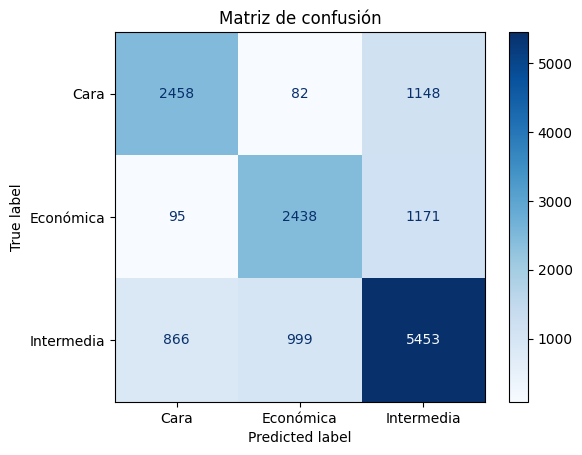

In [ ]:
class_names = [str(c) for c in mejor_modelo.classes_]
cm = confusion_matrix(y_test, y_pred, labels=mejor_modelo.classes_)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusión")
plt.show()

### ¿Puede estar sobreajustado? (Inciso 7)

In [13]:
y_pred_train = modelo.predict(X_train)
accuracy_train = accuracy_score(y_train, y_pred_train)
print("Exactitud del modelo:", accuracy_train)

Exactitud del modelo: 0.8029878142048641


La diferencia en el accuracy es de alrededor de 0.1 con el conjunto de entrenamiento, lo cual puede significar que para los parámetros utilizados se generó un modelo sobreajustado.

### Conclusiones

El algoritmo etiqueta considerablemente bien la clase "Intermedia", colocando correctamente el 74.5% de las etiquetas, siendo mucho mejor que el azar.

El algoritmo lo hace algo mal con las casas "Económicas", colocando correctamente el 65.8% de las etiquetas, siendo mejor que el azar, pero aún tiene muchos errores.  

El algoritmo lo hace algo mal con las casas "Cara", colocando correctamente el 66.6% de las etiquetas, siendo mejor que el azar, pero aún tiene muchos errores.

Por estas razones se considera que el modelo entrenado es capaz de realizar una categorización de las casas regular, todavía tiene muchos errores al momento de categorizar.
